Éxito importando data_pipeline desde: c:\Users\richi\Documents\S1_2026_Local\Proyecto_Mineria\MD_Proyecto1
Cargando panel histórico...
Cargando datos demográficos...
Unificando datos del censo...
Ejecutando KMeans...
Gráfico guardado en: c:\Users\richi\Documents\S1_2026_Local\Proyecto_Mineria\MD_Proyecto1\clusters\cluster_plot.png

--- Perfil Promedio por Cluster ---
   Cluster  TasaVIF  TasaDiv  pct_educacion_superior  pct_uniones_hecho  \
0        0   194.46    53.24                    4.96              19.81   
1        1   476.28    48.79                    4.38              16.47   
2        2   158.12    22.29                    2.46              18.04   

   poblacion  
0 714,388.90  
1 347,156.00  
2 796,096.62  


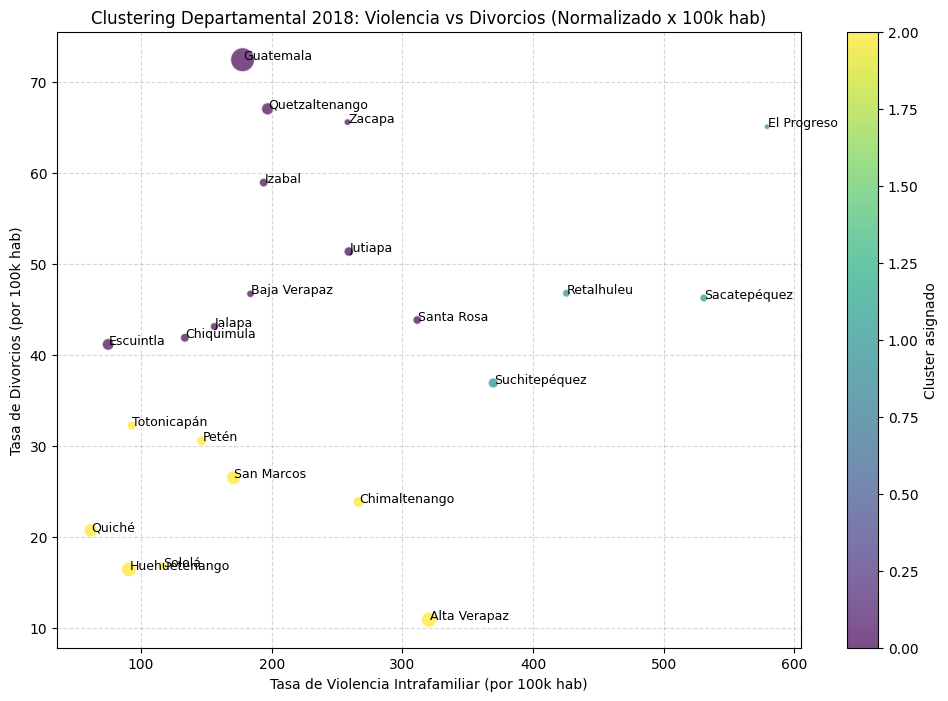

In [4]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ---------------------------------------------------------
# 0. CONFIGURACIÓN DEL PATH
# ---------------------------------------------------------
current_dir = Path.cwd()

# Buscamos la raíz del proyecto (donde está data_pipeline.py)
if current_dir.name in ['clusters', 'Analisis_Exploratorio_EDA']:
    project_root = current_dir.parent
else:
    if (current_dir / "data_pipeline.py").exists():
        project_root = current_dir
    elif (current_dir.parent / "data_pipeline.py").exists():
        project_root = current_dir.parent
    else:
        project_root = current_dir

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

try:
    import data_pipeline as dp
    print(f"Éxito importando data_pipeline desde: {project_root}")
except ImportError as e:
    print(f"Error importando data_pipeline: {e}")
    sys.exit(1)

# ---------------------------------------------------------
# 1. CARGA DE DATOS
# ---------------------------------------------------------
print("Cargando panel histórico...")
df_panel = dp.build_panel(force_rebuild=False)

# Rutas a los CSVs demográficos
path_poblacion = project_root / 'Datos' / 'Poblacion' / 'poblacion_total.csv'
path_educacion = project_root / 'Datos' / 'Poblacion' / 'nivel_educativo.csv'
path_civil = project_root / 'Datos' / 'Poblacion' / 'estado_civil.csv'

# Cargar CSVs
print("Cargando datos demográficos...")
try:
    df_poblacion = pd.read_csv(path_poblacion) 
    df_educacion = pd.read_csv(path_educacion)
    df_civil = pd.read_csv(path_civil)
except FileNotFoundError as e:
    print(f"Error cargando archivos CSV: {e}")
    sys.exit(1)

# Renombrar columnas para estandarizar 'departamento' y preparar features
# Poblacion
df_poblacion = df_poblacion.rename(columns={
    'Departamento': 'departamento',
    'Población total censada': 'poblacion'
})

# Educacion
df_educacion = df_educacion.rename(columns={'Departamento': 'departamento'})
# Crear feature de educacion superior si no existe
if 'pct_educacion_superior' not in df_educacion.columns:
    # Sumar Licenciatura y Maestria/Doc
    sup = df_educacion['Superior_Licenciatura'] + df_educacion['Superior_Maestria_Doc']
    df_educacion['pct_educacion_superior'] = (sup / df_educacion['Poblacion_4_mas']) * 100

# Estado Civil
df_civil = df_civil.rename(columns={'Departamento': 'departamento'})
# Crear feature de uniones de hecho
if 'pct_uniones_hecho' not in df_civil.columns:
    df_civil['pct_uniones_hecho'] = (df_civil['Unido'] / df_civil['Población_10_mas']) * 100

# Normalizar departamentos (usar la misma logica de data_pipeline si es necesario, 
# pero asumiremos que coinciden mayormente. data_pipeline usa slugify, aqui estan con mayusculas/tildes en el CSV)
# El merge funcionará si los strings son identicos.
# Revisemos data_pipeline.py: usa Canonical departments (Title Case con tildes).
# Los CSVs parecen tener "Guatemala", "El Progreso", "Sacatepéquez", etc. (Title Case con tildes).
# Asi que deberia funcionar directo el merge.

# Unificar datos del censo 2018
print("Unificando datos del censo...")
df_censo_2018 = df_poblacion.merge(df_educacion, on='departamento').merge(df_civil, on='departamento')

# ---------------------------------------------------------
# 2. PREPARACIÓN Y NORMALIZACIÓN
# ---------------------------------------------------------
# Filtrar solo 2018 del panel
df_2018 = df_panel[df_panel['anio'] == 2018].copy()

# Unir panel con censo
# df_panel tiene nombres canonicos normalizados? 
# build_panel -> _aggregate_divorcios -> _standardize_department -> CANONICAL_DEPARTMENTS (Title Case)
# Entonces debería hacer match.
df_final = df_2018.merge(df_censo_2018, on='departamento', how='inner')

if df_final.empty:
    print("Error: El DataFrame final está vacío después del merge.")
    print("Posible causa: Nombres de departamentos no coinciden.")
    print("Nombres en Panel (sample):", df_2018['departamento'].unique()[:5])
    print("Nombres en Censo (sample):", df_censo_2018['departamento'].unique()[:5])
    sys.exit(1)

# Calcular Tasas por 100,000 habitantes
df_final['TasaVIF'] = (df_final['vif_total'] / df_final['poblacion']) * 100000
df_final['TasaDiv'] = (df_final['divorcios_total'] / df_final['poblacion']) * 100000

# Escalamiento para K-Means
features = ['TasaVIF', 'TasaDiv']
# Verificar NAs
if df_final[features].isna().any().any():
    print("Advertencia: Hay valores nulos en las features. Se rellenarán con 0.")
    df_final[features] = df_final[features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_final[features])

# ---------------------------------------------------------
# 3. MODELADO (K-Means)
# ---------------------------------------------------------
print("Ejecutando KMeans...")
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
df_final['Cluster'] = kmeans.fit_predict(X_scaled)

# ---------------------------------------------------------
# 4. VISUALIZACIÓN
# ---------------------------------------------------------
plt.figure(figsize=(12, 8))
try:
    scatter = plt.scatter(
        df_final['TasaVIF'], 
        df_final['TasaDiv'], 
        c=df_final['Cluster'], 
        s=df_final['poblacion'] / 10000,
        cmap='viridis', 
        alpha=0.7,
        edgecolors='w'
    )

    for i, row in df_final.iterrows():
        plt.text(
            row['TasaVIF'] + 0.5,
            row['TasaDiv'], 
            row['departamento'], 
            fontsize=9
        )

    plt.title('Clustering Departamental 2018: Violencia vs Divorcios (Normalizado x 100k hab)')
    plt.xlabel('Tasa de Violencia Intrafamiliar (por 100k hab)')
    plt.ylabel('Tasa de Divorcios (por 100k hab)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.colorbar(scatter, label='Cluster asignado')

    output_img = project_root / 'clusters' / 'cluster_plot.png'
    plt.savefig(output_img)
    print(f"Gráfico guardado en: {output_img}")
except Exception as e:
    print(f"Error generando gráfico: {e}")

# ---------------------------------------------------------
# 5. PERFILAMIENTO
# ---------------------------------------------------------
cols_perfil = ['TasaVIF', 'TasaDiv', 'pct_educacion_superior', 'pct_uniones_hecho', 'poblacion']
# Asegurar que existan
cols_perfil = [c for c in cols_perfil if c in df_final.columns]

perfil = df_final.groupby('Cluster')[cols_perfil].mean().reset_index()

pd.options.display.float_format = '{:,.2f}'.format
print("\n--- Perfil Promedio por Cluster ---")
print(perfil)

ddddddddddddd

Éxito importando data_pipeline desde: c:\Users\richi\Documents\S1_2026_Local\Proyecto_Mineria\MD_Proyecto1
Cargando panel histórico...
Cargando datos demográficos (Censo 2018)...
Calculando promedios 2021-2023...
Ejecutando KMeans (k=3)...
Gráfico guardado en: c:\Users\richi\Documents\S1_2026_Local\Proyecto_Mineria\MD_Proyecto1\clusters\cluster_promedio_reciente.png


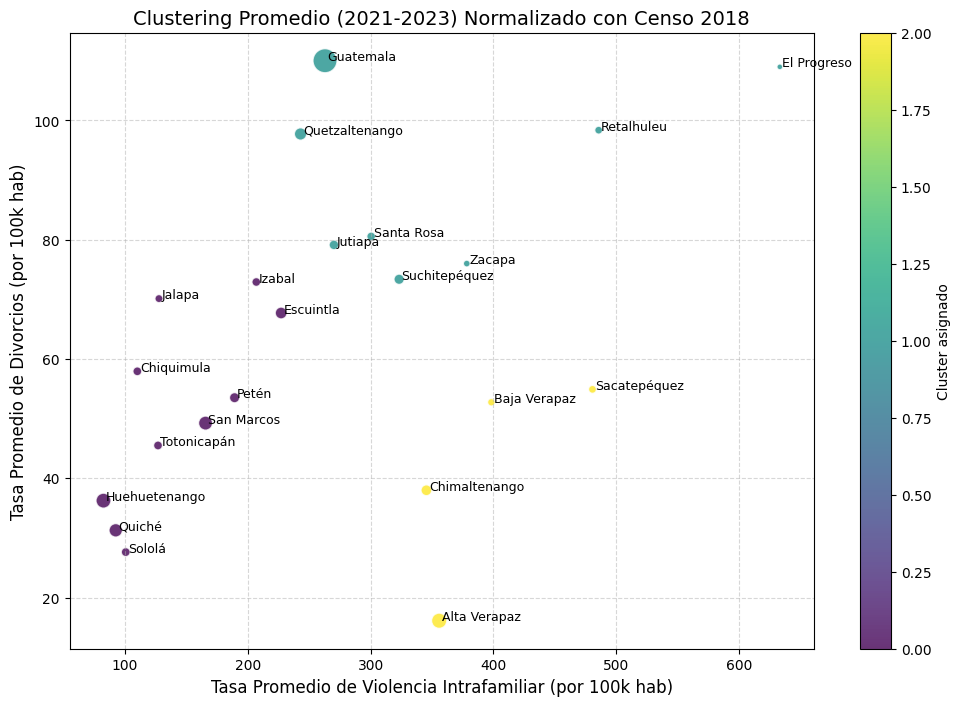


--- Perfil Promedio por Cluster (Datos Recientes Normalizados) ---
   Cluster  TasaVIF  TasaDiv  vif_promedio_anual  divorcios_promedio_anual  \
0        0   142.88    51.22              894.43                    310.45   
1        1   362.14    90.52            2,225.75                    738.94   
2        2   395.11    40.45            2,308.25                    192.38   

   pct_educacion_superior  pct_uniones_hecho  
0                    2.65              20.53  
1                    5.62              18.23  
2                    3.84              14.30  

--- Departamentos por Cluster ---
Cluster 0: Chiquimula, Escuintla, Huehuetenango, Izabal, Jalapa, Petén, Quiché, San Marcos, Sololá, Totonicapán
Cluster 1: El Progreso, Guatemala, Jutiapa, Quetzaltenango, Retalhuleu, Santa Rosa, Suchitepéquez, Zacapa
Cluster 2: Alta Verapaz, Baja Verapaz, Chimaltenango, Sacatepéquez


In [5]:
current_dir = Path.cwd()

# Buscamos la raíz del proyecto
if current_dir.name in ['clusters', 'Analisis_Exploratorio_EDA']:
    project_root = current_dir.parent
else:
    if (current_dir / "data_pipeline.py").exists():
        project_root = current_dir
    elif (current_dir.parent / "data_pipeline.py").exists():
        project_root = current_dir.parent
    else:
        project_root = current_dir

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

try:
    import data_pipeline as dp
    print(f"Éxito importando data_pipeline desde: {project_root}")
except ImportError as e:
    print(f"Error importando data_pipeline: {e}")
    sys.exit(1)

# ---------------------------------------------------------
# 1. CARGA DE DATOS
# ---------------------------------------------------------
print("Cargando panel histórico...")
df_panel = dp.build_panel(force_rebuild=False)

# Rutas a los CSVs demográficos (Censo 2018)
path_poblacion = project_root / 'Datos' / 'Poblacion' / 'poblacion_total.csv'
path_educacion = project_root / 'Datos' / 'Poblacion' / 'nivel_educativo.csv'
path_civil = project_root / 'Datos' / 'Poblacion' / 'estado_civil.csv'

# Cargar CSVs
print("Cargando datos demográficos (Censo 2018)...")
try:
    df_poblacion = pd.read_csv(path_poblacion) 
    df_educacion = pd.read_csv(path_educacion)
    df_civil = pd.read_csv(path_civil)
except FileNotFoundError as e:
    print(f"Error cargando archivos CSV: {e}")
    sys.exit(1)

# --- PREPARAR DATOS DEL CENSO (Igual que antes) ---
df_poblacion = df_poblacion.rename(columns={'Departamento': 'departamento', 'Población total censada': 'poblacion'})
df_educacion = df_educacion.rename(columns={'Departamento': 'departamento'})
df_civil = df_civil.rename(columns={'Departamento': 'departamento'})

# Calcular % Educación Superior (Variable de contexto)
if 'pct_educacion_superior' not in df_educacion.columns:
    sup = df_educacion['Superior_Licenciatura'] + df_educacion['Superior_Maestria_Doc']
    df_educacion['pct_educacion_superior'] = (sup / df_educacion['Poblacion_4_mas']) * 100

# Calcular % Uniones de Hecho (Variable de contexto)
if 'pct_uniones_hecho' not in df_civil.columns:
    df_civil['pct_uniones_hecho'] = (df_civil['Unido'] / df_civil['Población_10_mas']) * 100

# Unificar todo el Censo 2018 en un solo DataFrame base
df_censo_base = df_poblacion.merge(df_educacion[['departamento', 'pct_educacion_superior']], on='departamento')\
                             .merge(df_civil[['departamento', 'pct_uniones_hecho']], on='departamento')

# ---------------------------------------------------------
# 2. CALCULAR EL PROMEDIO RECIENTE (La parte nueva)
# ---------------------------------------------------------
print("Calculando promedios 2021-2023...")

# Filtramos los últimos 3 años disponibles para suavizar tendencias
anios_interes = [2021, 2022, 2023]
df_reciente = df_panel[df_panel['anio'].isin(anios_interes)].copy()

# Agrupamos por departamento y sacamos la media (promedio)
df_promedio = df_reciente.groupby('departamento')[['vif_total', 'divorcios_total']].mean().reset_index()

# Renombramos para que sea claro
df_promedio = df_promedio.rename(columns={
    'vif_total': 'vif_promedio_anual',
    'divorcios_total': 'divorcios_promedio_anual'
})

# ---------------------------------------------------------
# 3. UNIR Y NORMALIZAR (Con Censo 2018)
# ---------------------------------------------------------
# Unimos los promedios de hoy con la población base de 2018
df_final = df_promedio.merge(df_censo_base, on='departamento', how='inner')

if df_final.empty:
    print("Error: DataFrame vacío tras el merge. Verifica los nombres de los departamentos.")
    sys.exit(1)

# --- CÁLCULO DE TASAS (NORMALIZACIÓN) ---
# Fórmula: (Promedio de Casos / Población 2018) * 100,000
df_final['TasaVIF'] = (df_final['vif_promedio_anual'] / df_final['poblacion']) * 100000
df_final['TasaDiv'] = (df_final['divorcios_promedio_anual'] / df_final['poblacion']) * 100000

# ---------------------------------------------------------
# 4. MODELADO (K-Means)
# ---------------------------------------------------------
# Preparamos las features para el modelo
features = ['TasaVIF', 'TasaDiv']
X = df_final[features].fillna(0)

# Escalamos (Obligatorio)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Ejecutando KMeans (k=3)...")
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
df_final['Cluster'] = kmeans.fit_predict(X_scaled)

# ---------------------------------------------------------
# 5. VISUALIZACIÓN
# ---------------------------------------------------------
plt.figure(figsize=(12, 8))

# Scatter Plot
scatter = plt.scatter(
    df_final['TasaVIF'], 
    df_final['TasaDiv'], 
    c=df_final['Cluster'], 
    s=df_final['poblacion'] / 10000, # Tamaño burbuja por población para contexto
    cmap='viridis', 
    alpha=0.8,
    edgecolors='w'
)

# Etiquetas de texto
for i, row in df_final.iterrows():
    plt.text(
        row['TasaVIF'] + 2, # Un poco a la derecha
        row['TasaDiv'], 
        row['departamento'], 
        fontsize=9
    )

plt.title('Clustering Promedio (2021-2023) Normalizado con Censo 2018', fontsize=14)
plt.xlabel('Tasa Promedio de Violencia Intrafamiliar (por 100k hab)', fontsize=12)
plt.ylabel('Tasa Promedio de Divorcios (por 100k hab)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.colorbar(scatter, label='Cluster asignado')

# Guardar
output_img = project_root / 'clusters' / 'cluster_promedio_reciente.png'
# Crear carpeta si no existe
output_img.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_img)
print(f"Gráfico guardado en: {output_img}")
plt.show()

# ---------------------------------------------------------
# 6. PERFILAMIENTO Y RESULTADOS
# ---------------------------------------------------------
pd.options.display.float_format = '{:,.2f}'.format

# Agrupamos por cluster para ver los promedios
cols_perfil = ['TasaVIF', 'TasaDiv', 'vif_promedio_anual', 'divorcios_promedio_anual', 'pct_educacion_superior', 'pct_uniones_hecho']
perfil = df_final.groupby('Cluster')[cols_perfil].mean().reset_index()

print("\n--- Perfil Promedio por Cluster (Datos Recientes Normalizados) ---")
print(perfil)
print("\n--- Departamentos por Cluster ---")
for c in sorted(df_final['Cluster'].unique()):
    deptos = df_final[df_final['Cluster'] == c]['departamento'].tolist()
    print(f"Cluster {c}: {', '.join(deptos)}")